### Project Overview

This project analyzes taxi trip data to uncover patterns in trip behavior and build a machine learning model to predict trip duration.

The workflow includes:
- Data cleaning and feature engineering
- Exploratory data analysis and visualization
- Machine learning modeling and evaluation

The goal is to understand ley factors influencing trip duration and demonstrate an end-to-end data science pipeline

In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/xiluvamabasa/nyc-trip-data/NYC.csv


In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/xiluvamabasa/nyc-trip-data/NYC.csv')

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


### Insight
The dataset has no missing values.
Data type of column pickup_datetime and dropoff_time is object, it will need to be corrected.

In [4]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [5]:
# Correct data types
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

#Remove impossible durations e.g trip_duration <=0
df = df[df['trip_duration'] > 0]

df.dtypes

id                            object
vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime      datetime64[ns]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
dtype: object

In [18]:
#Extract datetime features
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['hour'] = df['pickup_datetime'].dt.hour

#Calculate Harvesine distance
def haversine_distance(lat1, lon1, lat2, lon2):

    #convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

df['distance_km'] = haversine_distance(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])

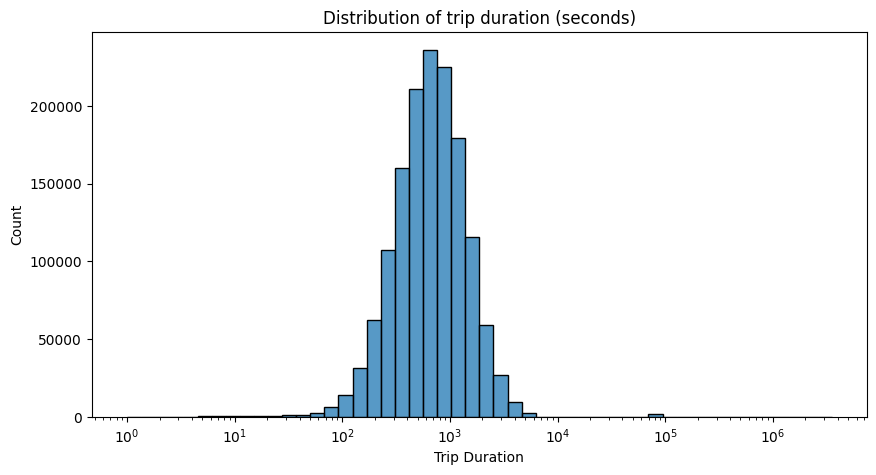

In [22]:
# Histogram of trip durations
plt.figure(figsize=(10,5))
sns.histplot(df['trip_duration'], bins=50, log_scale=True)
plt.title('Distribution of trip duration (seconds)')
plt.xlabel('Trip Duration')
plt.show()

In [8]:
# Trips per hour
df_sample= df.sample(5000, random_state=42 )
fig = px.scatter_mapbox(df_sample, lat='pickup_latitude', lon='pickup_longitude',
                       color='trip_duration', size='distance_km',
                       color_continuous_scale= 'Viridis', 
                       zoom=10, height=500,
                        title='Sample of NYC pickups')
                    
fig.update_layout(mapbox_style='open-street-map')
fig.show()

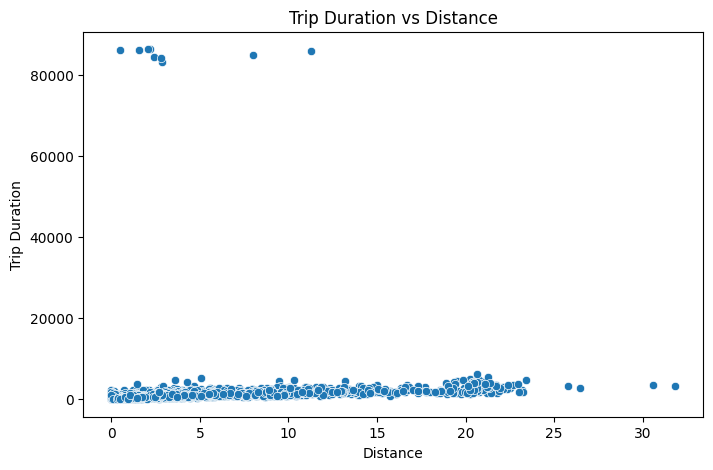

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='distance_km', y='trip_duration', data=df.sample(5000))
plt.xlabel('Distance')
plt.ylabel('Trip Duration')
plt.title('Trip Duration vs Distance')
plt.show()

In [19]:
# Machine Learning
features = ['passenger_count', 'distance_km', 'hour', 'day_of_week', 'month']
X = df[features]
y = df['trip_duration']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Linear Regression RMSE: 3213.743539864567
Random Forest RMSE: 3212.239525844434


### Model performance/evaluation
- The Random Forest model achieved a lower RMSE compared to Linear Regression.
- This indicates better performance due to its ability to capture non-linear relationships.
- Distance and time-based features significantly improved prediction accuracy.

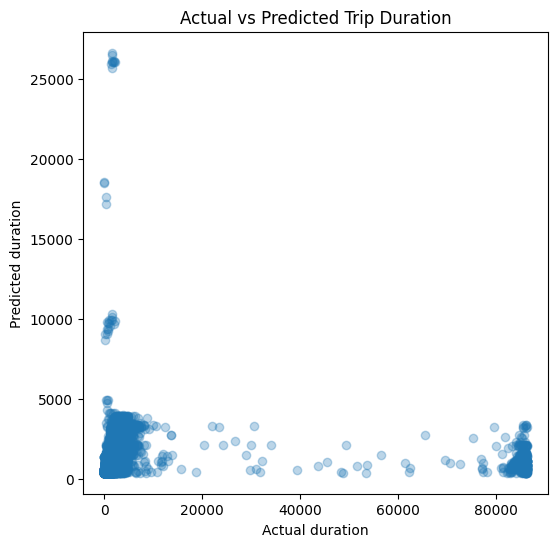

In [21]:
# Prediction vs actual plot

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel('Actual duration')
plt.ylabel('Predicted duration')
plt.title('Actual vs Predicted Trip Duration')
plt.show()

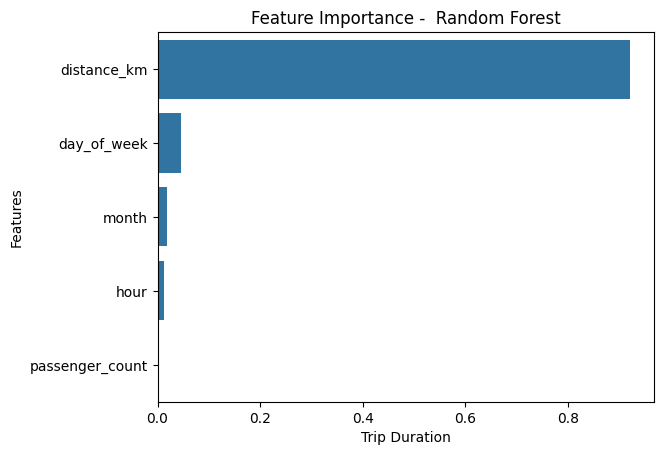

In [27]:
#feature importance for Random Forest
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index)
plt.xlabel('Trip Duration')
plt.ylabel('Features')
plt.title('Feature Importance -  Random Forest')
plt.show()

### Insight

- Trip duration increases significantly with distance, confirming it is the strongest predictor
- Passenger count has minimal impact on trip duration